# Threshold Analysis for CogAtlas Term Selection (v2)

This notebook analyzes cosine similarity scores between brain images and CogAtlas terms to find an optimal threshold for term selection.

## Problem
Currently, we use **top-5** terms (or top-2 per category) for each brain image. However:
- Some images may have 15 highly similar terms (we're cutting off relevant terms)
- Other images may only have 3 highly similar terms (we're including irrelevant terms)

## Solution
Find a **cosine similarity threshold** that:
- Captures all truly related terms
- Excludes unrelated terms
- Adapts to each image (variable number of terms per image)

## Approach
1. Use `search_cogatlas_from_brain` to get ALL CogAtlas terms ranked by similarity
2. Collect similarity scores across all images and categories
3. Plot histograms to visualize distribution
4. Identify threshold where there's a clear drop-off in similarity
5. Create new dataset with dynamic threshold

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys
from pathlib import Path
from tqdm import tqdm
import json
import pickle

sys.path.append('../../')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Step 1: Load Brain Vectors and CogAtlas Metadata

In [2]:
from src.neurovlm.retrieval_resources import (
    _load_latent_neuro,
    _load_cogatlas_dataset,
    _load_cogatlas_task_dataset,
    _load_cogatlas_disorder_dataset
)
from src.neurovlm.brain_input import search_cogatlas_from_brain

# Load raw brain vectors (search_cogatlas_from_brain handles projection)
print("Loading brain vectors...")
brain_vectors, brain_pmids = _load_latent_neuro()
print(f"Brain vectors: {brain_vectors.shape}")
print(f"PMIDs: {len(brain_pmids)}")

# Load CogAtlas datasets to get term counts
print("\nLoading CogAtlas datasets...")
cogatlas_concepts = _load_cogatlas_dataset()
cogatlas_tasks = _load_cogatlas_task_dataset()
cogatlas_disorders = _load_cogatlas_disorder_dataset()

n_concepts = len(cogatlas_concepts)
n_tasks = len(cogatlas_tasks)
n_disorders = len(cogatlas_disorders)
n_total = n_concepts + n_tasks + n_disorders

print(f"\nCogAtlas term counts:")
print(f"  Concepts: {n_concepts}")
print(f"  Tasks: {n_tasks}")
print(f"  Disorders: {n_disorders}")
print(f"  TOTAL: {n_total}")

Loading brain vectors...
Brain vectors: torch.Size([29868, 384])
PMIDs: 29868

Loading CogAtlas datasets...

CogAtlas term counts:
  Concepts: 911
  Tasks: 852
  Disorders: 221
  TOTAL: 1984


## Step 2: Get the cosine similarity for each term based on each brain

In [ ]:
from neurovlm.retrieval_resources import _load_threshold_analysis_cache

# Check if cached data exists
cache_file = 'threshold_analysis_similarities_cache.pkl'
SKIP_COMPUTATION = False

try:
    print("Loading cached similarities from HuggingFace...")
    cache_data = _load_threshold_analysis_cache()

    all_similarities = cache_data['all_similarities']
    all_terms = cache_data['all_terms']
    all_categories = cache_data['all_categories']
    top_k_similarities = cache_data['top_k_similarities']
    n_samples = cache_data['n_samples']
    sample_indices = cache_data['sample_indices']

    print(f"✓ Loaded {len(all_similarities):,} similarity scores")
    print(f"\nSimilarity statistics:")
    print(f"  Min:  {all_similarities.min():.4f}")
    print(f"  Max:  {all_similarities.max():.4f}")
    print(f"  Mean: {all_similarities.mean():.4f}")
    print(f"  Std:  {all_similarities.std():.4f}")
    print("\n⚠️  Skip to Step 3 (cell after this) to continue with visualization...")

    SKIP_COMPUTATION = True
except Exception as e:
    print(f"Could not load cached data from HuggingFace: {e}")
    print("Will compute similarities (this takes ~2 hours for all 29,868 images)...")

In [14]:
if not SKIP_COMPUTATION:
    # Sample images to analyze (use all images)
    n_samples = min(29868, len(brain_vectors))  # Analyze all 29,868 images
    sample_indices = np.random.choice(len(brain_vectors), n_samples, replace=False)

    print(f"Analyzing {n_samples} randomly sampled images...")
    print("⏱️  This will take approximately 2 hours...\n")

    # Store all similarities
    all_similarities = []
    all_terms = []
    all_categories = []

    # Also track top-k for comparison
    top_k_similarities = {k: [] for k in [5, 10, 15, 20]}

    # Process each category
    for category, category_name, n_terms in [
        ("cogatlas", "concepts", n_concepts),
        ("cogatlas_task", "tasks", n_tasks),
        ("cogatlas_disorder", "disorders", n_disorders)
    ]:
        print(f"Processing {category_name} ({n_terms} terms)...")

        for idx in tqdm(sample_indices, desc=f"  {category_name}"):
            brain_vec = brain_vectors[idx]

            # Get ALL terms for this category ranked by similarity
            _, terms, similarities = search_cogatlas_from_brain(
                query=brain_vec,
                top_k=n_terms,  # Get all terms
                category=category
            )

            # Store data
            all_similarities.extend(similarities.tolist())
            all_terms.extend(terms)
            all_categories.extend([category_name] * len(terms))

            # Track top-k
            for k in top_k_similarities.keys():
                if k <= len(similarities):
                    top_k_similarities[k].extend(similarities[:k].tolist())

    all_similarities = np.array(all_similarities)

    print(f"\n{'='*70}")
    print(f"Collected {len(all_similarities):,} similarity scores")
    print(f"  From {n_samples} images × {n_total} terms = {n_samples * n_total:,}")
    print(f"\nSimilarity statistics:")
    print(f"  Min:  {all_similarities.min():.4f}")
    print(f"  Max:  {all_similarities.max():.4f}")
    print(f"  Mean: {all_similarities.mean():.4f}")
    print(f"  Std:  {all_similarities.std():.4f}")
    print(f"{'='*70}")
    
    # Save cache to avoid recomputation
    print(f"\n💾 Saving computed data to cache...")
    cache_data = {
        'all_similarities': all_similarities,
        'all_terms': all_terms,
        'all_categories': all_categories,
        'top_k_similarities': top_k_similarities,
        'n_samples': n_samples,
        'sample_indices': sample_indices
    }
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)
    
    print(f"✓ Saved to: {cache_file}")
    print(f"  File size: {Path(cache_file).stat().st_size / 1024 / 1024:.1f} MB")
    print("\n💡 Next time you run this notebook, you can load this cache to skip the 2-hour computation!")
else:
    print("✓ Using cached data - skipping 2-hour computation")

✓ Using cached data - skipping 2-hour computation


In [12]:
# OPTIONAL: Save current data to cache (run this once to save your 2-hour computation!)
save_to_cache = True  # Set to True to save

if save_to_cache and 'all_similarities' in locals():
    cache_file = 'threshold_analysis_similarities_cache.pkl'
    
    print("💾 Saving computed data to cache...")
    cache_data = {
        'all_similarities': all_similarities,
        'all_terms': all_terms,
        'all_categories': all_categories,
        'top_k_similarities': top_k_similarities,
        'n_samples': n_samples,
        'sample_indices': sample_indices
    }
    
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)
    
    print(f"✓ Saved to: {cache_file}")
    print(f"  File size: {Path(cache_file).stat().st_size / 1024 / 1024:.1f} MB")
    print("\n💡 Next time you run this notebook, the cache will be detected and loaded automatically!")
else:
    print("Skipping cache save (set save_to_cache=True to save)")

💾 Saving computed data to cache...
✓ Saved to: threshold_analysis_similarities_cache.pkl
  File size: 881.0 MB

💡 Next time you run this notebook, the cache will be detected and loaded automatically!


## Step 3: Investigate Similarity Distribution

Before visualizing, let's understand how similarities are distributed per-image.

Analyzing per-image similarity distributions...

Per-Image Statistics (first 1000 images):
----------------------------------------------------------------------
Max similarity per image:
  Mean: 0.3802
  Median: 0.3790
  Min: 0.1864
  Max: 0.5454
  Std: 0.0480

Mean similarity per image:
  Mean: 0.0187
  Median: 0.0185
  Range: -0.0900 to 0.1343

Images with max similarity < 0.15: 0 (0.0%)
Images with max similarity < 0.20: 2 (0.0%)


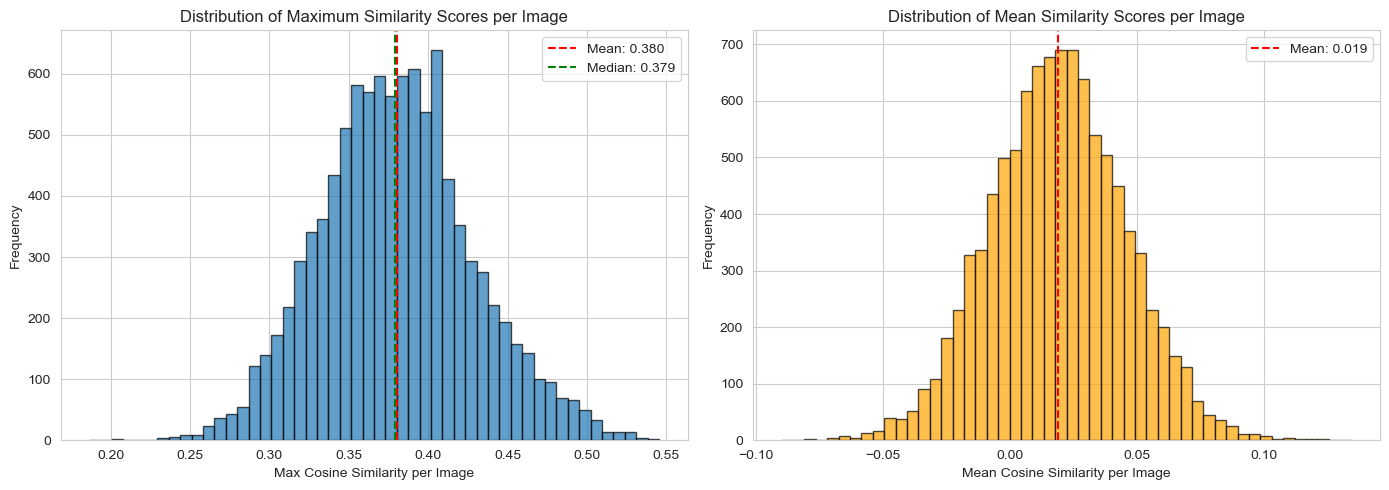


ANALYSIS

✓ Similarity distributions look reasonable for threshold-based selection


In [31]:
1# Investigate per-image statistics
print("Analyzing per-image similarity distributions...\n")

# Calculate max similarity per image
max_sims_per_image = []
mean_sims_per_image = []
std_sims_per_image = []

for img_idx in range(min(n_samples, 10000)):  # Check first 1000 images
    start_idx = img_idx * n_total
    end_idx = start_idx + n_total
    img_similarities = all_similarities[start_idx:end_idx]
    
    max_sims_per_image.append(img_similarities.max())
    mean_sims_per_image.append(img_similarities.mean())
    std_sims_per_image.append(img_similarities.std())

max_sims_per_image = np.array(max_sims_per_image)
mean_sims_per_image = np.array(mean_sims_per_image)
std_sims_per_image = np.array(std_sims_per_image)

print("Per-Image Statistics (first 1000 images):")
print("-" * 70)
print(f"Max similarity per image:")
print(f"  Mean: {max_sims_per_image.mean():.4f}")
print(f"  Median: {np.median(max_sims_per_image):.4f}")
print(f"  Min: {max_sims_per_image.min():.4f}")
print(f"  Max: {max_sims_per_image.max():.4f}")
print(f"  Std: {max_sims_per_image.std():.4f}")

print(f"\nMean similarity per image:")
print(f"  Mean: {mean_sims_per_image.mean():.4f}")
print(f"  Median: {np.median(mean_sims_per_image):.4f}")
print(f"  Range: {mean_sims_per_image.min():.4f} to {mean_sims_per_image.max():.4f}")

print(f"\nImages with max similarity < 0.15: {(max_sims_per_image < 0.15).sum()} ({(max_sims_per_image < 0.15).sum() / len(max_sims_per_image) * 100:.1f}%)")
print(f"Images with max similarity < 0.20: {(max_sims_per_image < 0.20).sum()} ({(max_sims_per_image < 0.20).sum() / len(max_sims_per_image) * 100:.1f}%)")

# Plot distribution of max similarities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_sims_per_image, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Max Cosine Similarity per Image')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Maximum Similarity Scores per Image')
axes[0].axvline(max_sims_per_image.mean(), color='r', linestyle='--', 
                label=f'Mean: {max_sims_per_image.mean():.3f}')
axes[0].axvline(np.median(max_sims_per_image), color='g', linestyle='--',
                label=f'Median: {np.median(max_sims_per_image):.3f}')
axes[0].legend()

axes[1].hist(mean_sims_per_image, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Mean Cosine Similarity per Image')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Mean Similarity Scores per Image')
axes[1].axvline(mean_sims_per_image.mean(), color='r', linestyle='--',
                label=f'Mean: {mean_sims_per_image.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ANALYSIS")
print("=" * 70)

if np.median(max_sims_per_image) < 0.2:
    print("\n⚠️  WARNING: Many images have very low maximum similarities!")
    print("   This suggests:")
    print("   1. Many brain images may not match well with CogAtlas terms")
    print("   2. The embeddings may need better alignment")
    print("   3. Consider using per-image percentile thresholds instead")
    print("      (e.g., top-K approach rather than absolute threshold)")
else:
    print("\n✓ Similarity distributions look reasonable for threshold-based selection")

## Step 4: Analyze Top-K Distributions

Compare current top-5 approach with top-10, top-15, top-20.

Top-5 statistics:
  Mean:   0.2368
  Median: 0.2378
  Min:    -0.1596
  25th %ile: 0.1860

Top-10 statistics:
  Mean:   0.2176
  Median: 0.2182
  Min:    -0.1738
  25th %ile: 0.1657

Top-15 statistics:
  Mean:   0.2043
  Median: 0.2048
  Min:    -0.1991
  25th %ile: 0.1516

Top-20 statistics:
  Mean:   0.1940
  Median: 0.1944
  Min:    -0.2159
  25th %ile: 0.1405



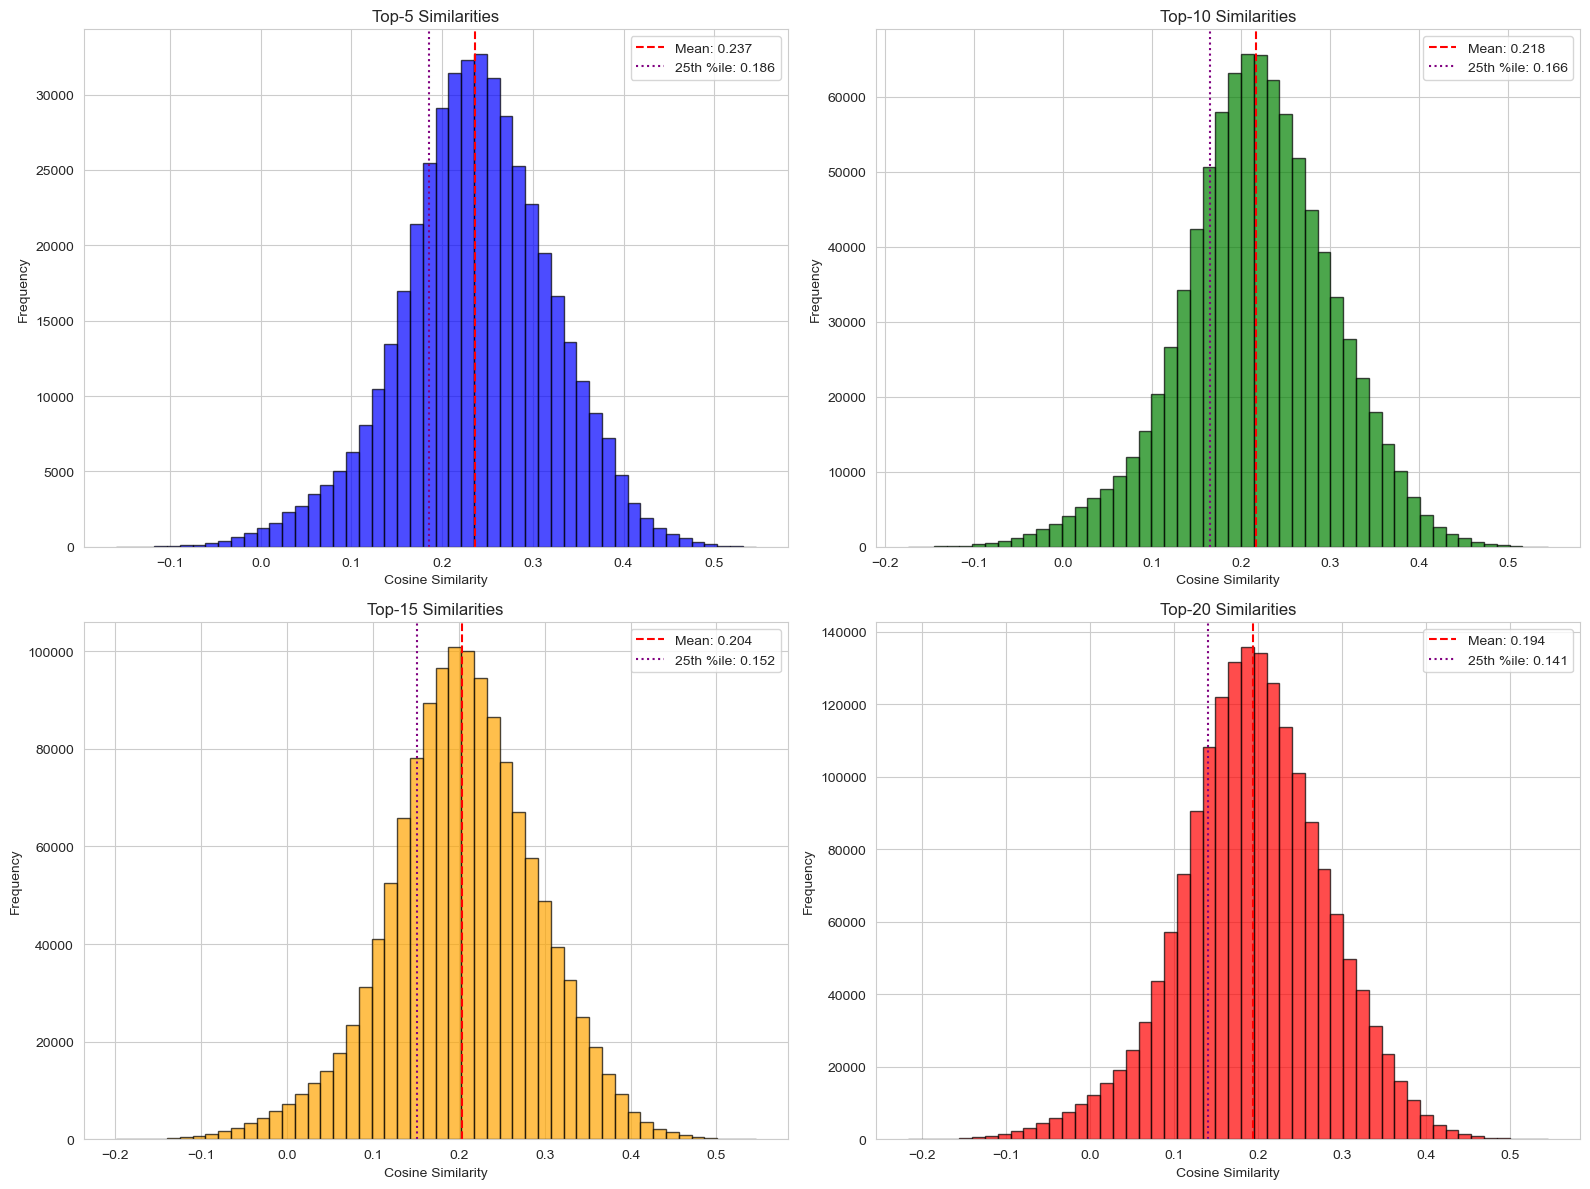

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['blue', 'green', 'orange', 'red']

for i, (k, sims) in enumerate(top_k_similarities.items()):
    sims_arr = np.array(sims)
    
    axes[i].hist(sims_arr, bins=50, alpha=0.7, edgecolor='black', color=colors[i])
    axes[i].set_xlabel('Cosine Similarity')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Top-{k} Similarities')
    axes[i].axvline(sims_arr.mean(), color='r', linestyle='--',
                   label=f'Mean: {sims_arr.mean():.3f}')
    axes[i].axvline(np.percentile(sims_arr, 25), color='purple', linestyle=':',
                   label=f'25th %ile: {np.percentile(sims_arr, 25):.3f}')
    axes[i].legend()
    
    print(f"Top-{k} statistics:")
    print(f"  Mean:   {sims_arr.mean():.4f}")
    print(f"  Median: {np.median(sims_arr):.4f}")
    print(f"  Min:    {sims_arr.min():.4f}")
    print(f"  25th %ile: {np.percentile(sims_arr, 25):.4f}")
    print()

plt.tight_layout()
plt.show()

## Step 5: Identify Threshold Candidates

In [17]:
# Calculate percentiles as potential thresholds
percentiles = [75, 80, 85, 90, 95, 99]
threshold_candidates = {}

print("=" * 70)
print("THRESHOLD CANDIDATES")
print("=" * 70)

for p in percentiles:
    threshold = np.percentile(all_similarities, p)
    threshold_candidates[p] = threshold
    
    # Estimate average terms per image
    n_above = (all_similarities > threshold).sum()
    avg_per_image = n_above / n_samples
    
    print(f"{p}th percentile: {threshold:.4f}")
    print(f"  → ~{avg_per_image:.1f} terms per image on average")
    print()

# Check current top-5 lower bound
top5_lower = np.percentile(top_k_similarities[5], 25)
print(f"\nCurrent top-5 approach:")
print(f"  25th percentile of top-5: {top5_lower:.4f}")
print(f"  (minimum similarity accepted in 25% of cases)")
print("=" * 70)

THRESHOLD CANDIDATES
75th percentile: 0.1051
  → ~204.2 terms per image on average

80th percentile: 0.1255
  → ~163.4 terms per image on average

85th percentile: 0.1492
  → ~122.6 terms per image on average

90th percentile: 0.1792
  → ~81.7 terms per image on average

95th percentile: 0.2238
  → ~40.8 terms per image on average

99th percentile: 0.3038
  → ~8.2 terms per image on average


Current top-5 approach:
  25th percentile of top-5: 0.1860
  (minimum similarity accepted in 25% of cases)


## Step 6: Per-Image Drop-off Analysis

Visualize how similarity drops off for individual images.

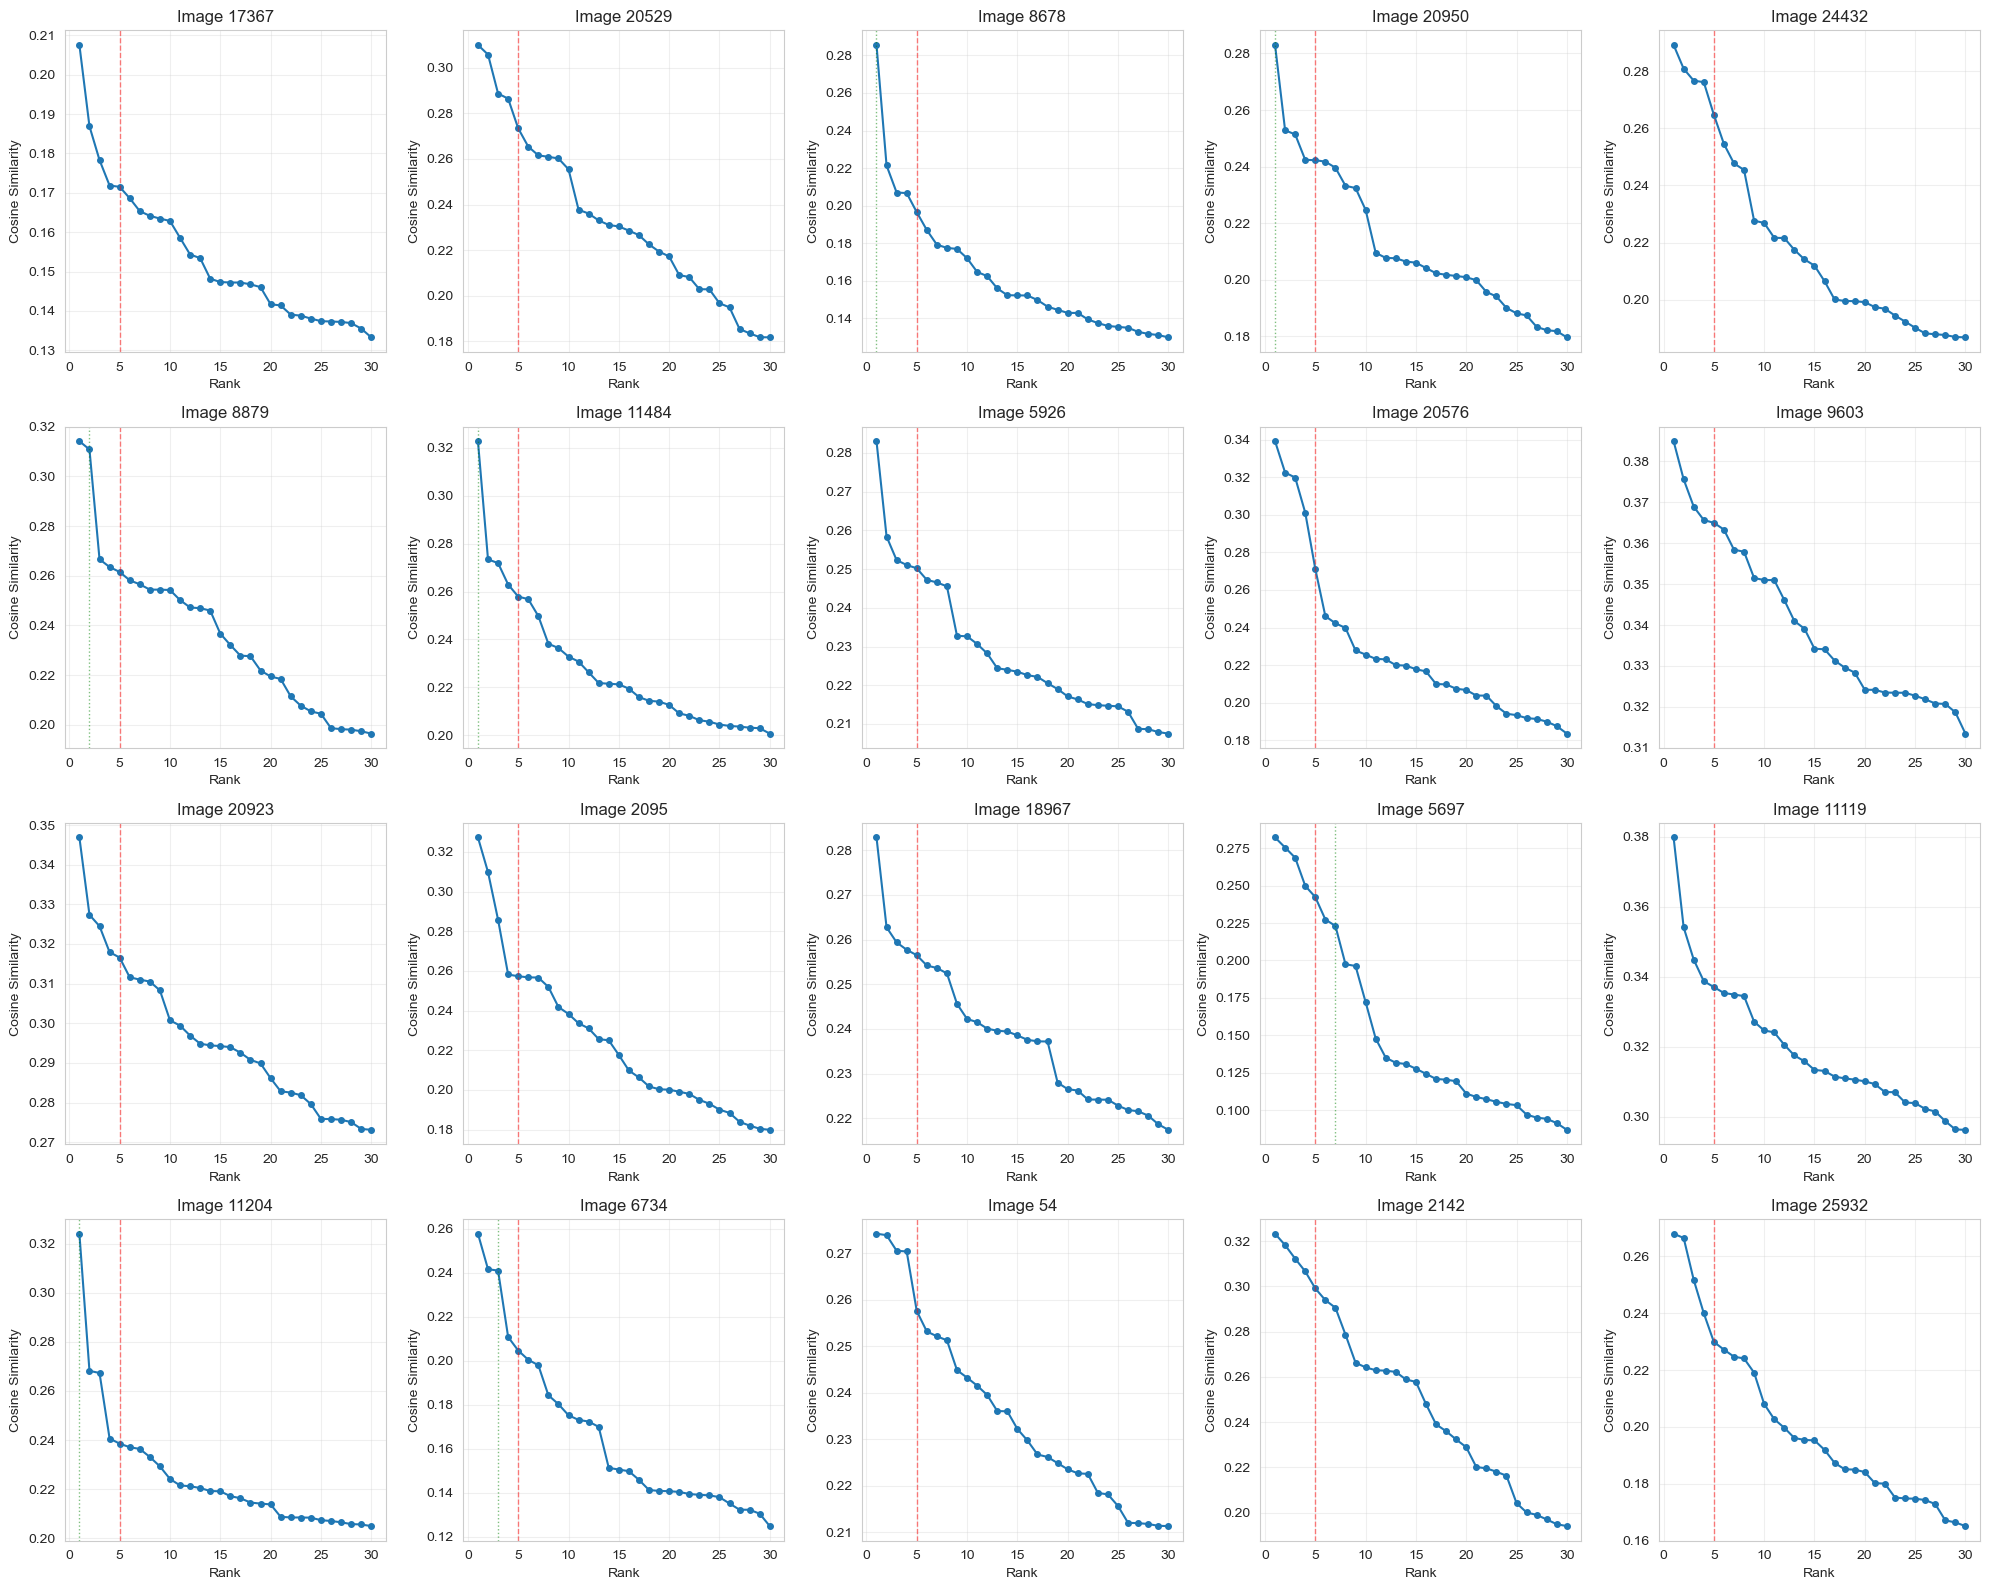


Drop-off analysis (>10% decrease):
  Mean position:   2.3
  Median position: 1.0
  Range: 1 to 7


In [18]:
# Sample 20 random images for visualization
sample_image_indices = np.random.choice(sample_indices, 20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

drop_off_positions = []

for plot_idx, img_idx in enumerate(sample_image_indices):
    brain_vec = brain_vectors[img_idx]
    
    # Get similarities across all categories
    all_sims_per_img = []
    
    for category, n_terms in [
        ("cogatlas", n_concepts),
        ("cogatlas_task", n_tasks),
        ("cogatlas_disorder", n_disorders)
    ]:
        _, _, similarities = search_cogatlas_from_brain(
            query=brain_vec,
            top_k=min(n_terms, 50),  # Get up to 50 per category
            category=category
        )
        all_sims_per_img.extend(similarities.tolist())
    
    # Sort and plot top 30
    sorted_sims = np.sort(all_sims_per_img)[::-1]
    top_30 = sorted_sims[:30]
    
    axes[plot_idx].plot(range(1, len(top_30)+1), top_30, marker='o', markersize=4)
    axes[plot_idx].set_xlabel('Rank')
    axes[plot_idx].set_ylabel('Cosine Similarity')
    axes[plot_idx].set_title(f'Image {img_idx}')
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].axvline(5, color='r', linestyle='--', alpha=0.5, linewidth=1)
    
    # Find drop-off point (>10% decrease)
    for i in range(1, len(top_30)):
        if top_30[i-1] > 0 and (top_30[i-1] - top_30[i]) / top_30[i-1] > 0.1:
            axes[plot_idx].axvline(i, color='green', linestyle=':', alpha=0.5, linewidth=1)
            drop_off_positions.append(i)
            break

plt.tight_layout()
plt.show()

if drop_off_positions:
    print(f"\nDrop-off analysis (>10% decrease):")
    print(f"  Mean position:   {np.mean(drop_off_positions):.1f}")
    print(f"  Median position: {np.median(drop_off_positions):.1f}")
    print(f"  Range: {min(drop_off_positions)} to {max(drop_off_positions)}")

## Step 7: Find Optimal Threshold Balance

Find the threshold that maximizes strictness while avoiding data loss (too many images with no/few terms).

In [21]:
# Analyze multiple threshold candidates
percentiles_to_test = [85, 90, 94, 95, 96, 97, 98, 99]

print("=" * 80)
print("THRESHOLD ANALYSIS: Finding Optimal Balance")
print("=" * 80)
print("\nTesting thresholds to maximize strictness while minimizing data loss...")
print("(Avoiding too many images with 0 or very few terms)\n")

# Calculate statistics for each threshold
print("Threshold Values:")
print("-" * 80)
for p in percentiles_to_test:
    threshold = np.percentile(all_similarities, p)
    n_above = (all_similarities > threshold).sum()
    avg_per_image = n_above / n_samples
    print(f"{p}th percentile: {threshold:.4f}  →  ~{avg_per_image:.1f} terms per image on average")

print("\n" + "=" * 80)
print("DATA DISTRIBUTION ANALYSIS")
print("=" * 80)

# Since all_similarities contains n_samples × n_total scores, 
# we need to reshape to analyze per-image
# Each image has n_total consecutive scores in all_similarities
terms_per_image_by_threshold = {}

for p in percentiles_to_test:
    threshold = np.percentile(all_similarities, p)
    
    # Count terms above threshold for each image
    terms_per_image = []
    
    # all_similarities is structured as: [img0_all_terms, img1_all_terms, ...]
    # where each image has n_total consecutive similarity scores
    for img_idx in range(n_samples):
        start_idx = img_idx * n_total
        end_idx = start_idx + n_total
        img_similarities = all_similarities[start_idx:end_idx]
        
        n_above = (img_similarities > threshold).sum()
        terms_per_image.append(n_above)
    
    terms_per_image = np.array(terms_per_image)
    
    # Calculate statistics
    n_images = len(terms_per_image)
    n_zero = (terms_per_image == 0).sum()
    n_5_or_less = (terms_per_image <= 5).sum()
    n_10_or_less = (terms_per_image <= 10).sum()
    n_at_least_10 = (terms_per_image >= 10).sum()
    n_at_least_15 = (terms_per_image >= 15).sum()
    n_at_least_20 = (terms_per_image >= 20).sum()
    n_at_least_30 = (terms_per_image >= 30).sum()
    
    terms_per_image_by_threshold[p] = {
        'threshold': threshold,
        'terms_per_image': terms_per_image,
        'mean': terms_per_image.mean(),
        'median': np.median(terms_per_image),
        'std': terms_per_image.std(),
        'min': terms_per_image.min(),
        'max': terms_per_image.max(),
        'n_zero': n_zero,
        'n_5_or_less': n_5_or_less,
        'n_10_or_less': n_10_or_less,
        'n_at_least_10': n_at_least_10,
        'n_at_least_15': n_at_least_15,
        'n_at_least_20': n_at_least_20,
        'n_at_least_30': n_at_least_30,
        'pct_zero': (n_zero / n_images) * 100,
        'pct_5_or_less': (n_5_or_less / n_images) * 100,
        'pct_10_or_less': (n_10_or_less / n_images) * 100,
        'pct_at_least_10': (n_at_least_10 / n_images) * 100,
        'pct_at_least_15': (n_at_least_15 / n_images) * 100,
        'pct_at_least_20': (n_at_least_20 / n_images) * 100,
        'pct_at_least_30': (n_at_least_30 / n_images) * 100
    }

print("\n" + "=" * 80)
print(f"RESULTS SUMMARY (analyzing all {n_samples:,} images)")
print("=" * 80)

# Create summary table
print(f"\n{'Percentile':<12} {'Threshold':<10} {'Mean':<8} {'Median':<8} {'Min':<6} {'Max':<6}")
print("-" * 80)
for p in percentiles_to_test:
    r = terms_per_image_by_threshold[p]
    print(f"{p}th{'':<9} {r['threshold']:<10.4f} {r['mean']:<8.1f} {r['median']:<8.0f} {r['min']:<6.0f} {r['max']:<6.0f}")

print("\n" + "=" * 80)
print(f"DATA LOSS ANALYSIS (out of {n_samples:,} images)")
print("=" * 80)

print(f"\n{'Percentile':<12} {'0 Terms':<18} {'≤5 Terms':<18} {'≤10 Terms':<18}")
print("-" * 80)
for p in percentiles_to_test:
    r = terms_per_image_by_threshold[p]
    print(f"{p}th{'':<9} {r['n_zero']:>6,} ({r['pct_zero']:>5.1f}%){'':<4} "
          f"{r['n_5_or_less']:>6,} ({r['pct_5_or_less']:>5.1f}%){'':<4} "
          f"{r['n_10_or_less']:>6,} ({r['pct_10_or_less']:>5.1f}%)")

print(f"\n{'Percentile':<12} {'≥10 Terms':<18} {'≥15 Terms':<18} {'≥20 Terms':<18} {'≥30 Terms':<18}")
print("-" * 80)
for p in percentiles_to_test:
    r = terms_per_image_by_threshold[p]
    print(f"{p}th{'':<9} {r['n_at_least_10']:>6,} ({r['pct_at_least_10']:>5.1f}%){'':<4} "
          f"{r['n_at_least_15']:>6,} ({r['pct_at_least_15']:>5.1f}%){'':<4} "
          f"{r['n_at_least_20']:>6,} ({r['pct_at_least_20']:>5.1f}%){'':<4} "
          f"{r['n_at_least_30']:>6,} ({r['pct_at_least_30']:>5.1f}%)")

print("\n" + "=" * 80)
print("RECOMMENDATION ANALYSIS")
print("=" * 80)

# Find best threshold based on criteria
# Good threshold: <5% images with 0 terms, <20% with ≤5 terms, majority have ≥10 terms
best_candidates = []

for p in percentiles_to_test:
    r = terms_per_image_by_threshold[p]
    
    # Criteria for a good threshold
    low_data_loss = r['pct_zero'] < 5.0  # Less than 5% images with 0 terms
    reasonable_coverage = r['pct_5_or_less'] < 20.0  # Less than 20% with ≤5 terms
    good_retention = r['pct_at_least_10'] > 60.0  # More than 60% have ≥10 terms
    
    if low_data_loss and reasonable_coverage and good_retention:
        best_candidates.append(p)

if best_candidates:
    print(f"\n✓ Recommended percentiles (meet all criteria):")
    for p in best_candidates:
        r = terms_per_image_by_threshold[p]
        print(f"  {p}th percentile (threshold={r['threshold']:.4f})")
        print(f"    → {r['pct_zero']:.1f}% with 0 terms, {r['pct_at_least_10']:.1f}% with ≥10 terms")
else:
    print("\n⚠️  No percentile meets all strict criteria. Relaxing requirements...")
    
    # Relaxed criteria
    for p in percentiles_to_test:
        r = terms_per_image_by_threshold[p]
        if r['pct_zero'] < 10.0 and r['pct_at_least_10'] > 50.0:
            best_candidates.append(p)
    
    if best_candidates:
        print(f"\n✓ Recommended percentiles (relaxed criteria):")
        for p in best_candidates:
            r = terms_per_image_by_threshold[p]
            print(f"  {p}th percentile (threshold={r['threshold']:.4f})")
            print(f"    → {r['pct_zero']:.1f}% with 0 terms, {r['pct_at_least_10']:.1f}% with ≥10 terms")

print("\n" + "=" * 80)
print("OPTIONAL THRESHOLDS")
print("=" * 80)

print("\nYou can choose any threshold based on your needs:")
print("  • More strict (95th-99th): Fewer but higher-confidence terms")
print("  • More inclusive (85th-94th): More terms but potentially noisier")
print("\nUse the statistics above to make an informed decision!")
print("=" * 80)

# Store recommended threshold for later use (you can change this)
if best_candidates:
    recommended_percentile = best_candidates[0]
else:
    recommended_percentile = 90  # Default fallback

recommended_threshold = terms_per_image_by_threshold[recommended_percentile]['threshold']
print(f"\n💡 Using {recommended_percentile}th percentile (threshold={recommended_threshold:.4f}) for dataset creation...")
print(f"   Change 'recommended_percentile' variable above to use a different threshold.")

THRESHOLD ANALYSIS: Finding Optimal Balance

Testing thresholds to maximize strictness while minimizing data loss...
(Avoiding too many images with 0 or very few terms)

Threshold Values:
--------------------------------------------------------------------------------
85th percentile: 0.1492  →  ~122.6 terms per image on average
90th percentile: 0.1792  →  ~81.7 terms per image on average
94th percentile: 0.2127  →  ~49.0 terms per image on average
95th percentile: 0.2238  →  ~40.8 terms per image on average
96th percentile: 0.2369  →  ~32.7 terms per image on average
97th percentile: 0.2528  →  ~24.5 terms per image on average
98th percentile: 0.2734  →  ~16.3 terms per image on average
99th percentile: 0.3038  →  ~8.2 terms per image on average

DATA DISTRIBUTION ANALYSIS

RESULTS SUMMARY (analyzing all 29,868 images)

Percentile   Threshold  Mean     Median   Min    Max   
--------------------------------------------------------------------------------
85th          0.1492     122.6

## Step 8: Create Dataset with Dynamic Threshold

In [ ]:
print("Creating dataset with dynamic threshold...\n")

# Structure: {pmid: {category: [terms], category_sims: [scores]}}
dynamic_labels = {}
dynamic_similarities = {}

for idx, pmid in enumerate(tqdm(brain_pmids, desc="Processing all images")):
    brain_vec = brain_vectors[idx]
    pmid_str = str(pmid.item() if isinstance(pmid, torch.Tensor) else pmid)
    
    dynamic_labels[pmid_str] = {}
    dynamic_similarities[pmid_str] = {}
    
    # Process each category
    for category, category_name, n_terms in [
        ("cogatlas", "concepts", n_concepts),
        ("cogatlas_task", "tasks", n_tasks),
        ("cogatlas_disorder", "disorders", n_disorders)
    ]:
        _, terms, similarities = search_cogatlas_from_brain(
            query=brain_vec,
            top_k=n_terms,
            category=category
        )
        
        # Filter by threshold
        above_threshold = similarities > recommended_threshold
        selected_terms = [terms[i] for i in range(len(terms)) if above_threshold[i]]
        selected_sims = similarities[above_threshold].tolist()
        
        dynamic_labels[pmid_str][category_name] = selected_terms
        dynamic_similarities[pmid_str][category_name] = selected_sims

print(f"\nProcessed {len(dynamic_labels)} images")

# Calculate statistics
terms_per_img_total = []
terms_per_category = {'concepts': [], 'tasks': [], 'disorders': []}

for pmid, labels in dynamic_labels.items():
    total = sum(len(labels[cat]) for cat in ['concepts', 'tasks', 'disorders'])
    terms_per_img_total.append(total)
    
    for cat in ['concepts', 'tasks', 'disorders']:
        terms_per_category[cat].append(len(labels[cat]))

print(f"\n{'='*70}")
print(f"DATASET STATISTICS")
print(f"{'='*70}")
print(f"\nOverall terms per image:")
print(f"  Mean:   {np.mean(terms_per_img_total):.1f}")
print(f"  Median: {np.median(terms_per_img_total):.0f}")
print(f"  Min:    {min(terms_per_img_total)}")
print(f"  Max:    {max(terms_per_img_total)}")

print(f"\nBy category:")
for cat in ['concepts', 'tasks', 'disorders']:
    cat_arr = np.array(terms_per_category[cat])
    print(f"  {cat.capitalize():12s} Mean: {cat_arr.mean():4.1f}, "
          f"Median: {np.median(cat_arr):3.0f}, "
          f"Range: {cat_arr.min():.0f}-{cat_arr.max():.0f}")
print(f"{'='*70}")

## Step 9: Save Dataset

In [ ]:
# Save to JSON file
output_file = 'cogatlas_dynamic_threshold_labels.json'

output_data = {
    'threshold': float(recommended_threshold),
    'labels': dynamic_labels,
    'similarities': dynamic_similarities,
    'metadata': {
        'num_images': len(dynamic_labels),
        'num_terms_total': n_total,
        'num_concepts': n_concepts,
        'num_tasks': n_tasks,
        'num_disorders': n_disorders,
        'mean_terms_per_image': float(np.mean(terms_per_img_total)),
        'median_terms_per_image': float(np.median(terms_per_img_total))
    }
}

with open(output_file, 'w') as f:
    json.dump(output_data, f, indent=2)

print(f"✓ Saved dataset to: {output_file}")
print(f"\nFile size: {Path(output_file).stat().st_size / 1024 / 1024:.1f} MB")

## Summary

This analysis provides:

1. **Recommended threshold**: Cosine similarity cutoff value for term selection
2. **Validation**: Histograms and per-image analysis showing the threshold is reasonable
3. **New dataset**: JSON file with variable number of terms per image, organized by category

### Dataset Structure
```json
{
  "threshold": 0.xxxx,
  "labels": {
    "pmid_123": {
      "concepts": ["term1", "term2", ...],
      "tasks": ["task1", "task2", ...],
      "disorders": ["disorder1", ...]
    },
    ...
  },
  "similarities": {...},
  "metadata": {...}
}
```

### Next Steps
- Convert JSON to `.npy` format (like existing `cogatlas_term_matrix.npy`)
- Train models using this new dataset
- Compare performance against fixed top-5 approach